In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")


In [2]:
# Load the cleaned datasets 
df_dengue = pd.read_csv('../data/processed/dengue_cleaned.csv')
df_weather = pd.read_csv('../data/processed/weather_cleaned.csv')

# Convert date columns to datetime
df_dengue['date'] = pd.to_datetime(df_dengue['date'])
df_weather['month'] = pd.to_datetime(df_weather['month'])

print("="*60)
print("DENGUE DATA (Weekly - Before Conversion)")
print("="*60)
print(f"Shape: {df_dengue.shape}")
print(f"Date range: {df_dengue['date'].min().date()} to {df_dengue['date'].max().date()}")
print(f"Total weeks: {len(df_dengue)}")
print("\nFirst 5 rows:")
print(df_dengue[['date', 'cases']].head())

print("\n" + "="*60)
print("WEATHER DATA (Monthly)")
print("="*60)
print(f"Shape: {df_weather.shape}")
print(f"Date range: {df_weather['month'].min().date()} to {df_weather['month'].max().date()}")
print("\nFirst 5 rows:")
print(df_weather.head())

DENGUE DATA (Weekly - Before Conversion)
Shape: (574, 7)
Date range: 2012-01-02 to 2022-12-26
Total weeks: 574

First 5 rows:
        date  cases
0 2012-01-02     74
1 2012-01-09     66
2 2012-01-16     61
3 2012-01-23     52
4 2012-01-30     85

WEATHER DATA (Monthly)
Shape: (529, 3)
Date range: 1982-01-01 to 2026-01-01

First 5 rows:
       month  rainfall  temperature
0 1982-01-01     107.1         23.3
1 1982-02-01      27.8         23.9
2 1982-03-01     160.8         24.3
3 1982-04-01     157.0         24.3
4 1982-05-01     102.2         25.2


In [4]:
# Extract year-month from dengue dates
df_dengue['year_month'] = df_dengue['date'].dt.to_period('M')

# Aggregate weekly data to monthly by summing all cases in each month
df_dengue_monthly = df_dengue.groupby('year_month').agg({
    'cases': 'sum', 
    'date': 'min'   
}).reset_index()

# Convert period back to timestamp
df_dengue_monthly['month'] = df_dengue_monthly['year_month'].dt.to_timestamp()

# Keep only needed columns
df_dengue_monthly = df_dengue_monthly[['month', 'cases']]

print("="*60)
print("DENGUE DATA (Converted to Monthly)")
print("="*60)
print(f"Shape: {df_dengue_monthly.shape}")
print(f"Total months: {len(df_dengue_monthly)}")
print(f"Date range: {df_dengue_monthly['month'].min().date()} to {df_dengue_monthly['month'].max().date()}")
print("\nFirst 10 months:")
print(df_dengue_monthly.head(10))


DENGUE DATA (Converted to Monthly)
Shape: (132, 2)
Total months: 132
Date range: 2012-01-01 to 2022-12-01

First 10 months:
       month  cases
0 2012-01-01    338
1 2012-02-01    258
2 2012-03-01    231
3 2012-04-01    363
4 2012-05-01    338
5 2012-06-01    468
6 2012-07-01    601
7 2012-08-01    436
8 2012-09-01    322
9 2012-10-01    520


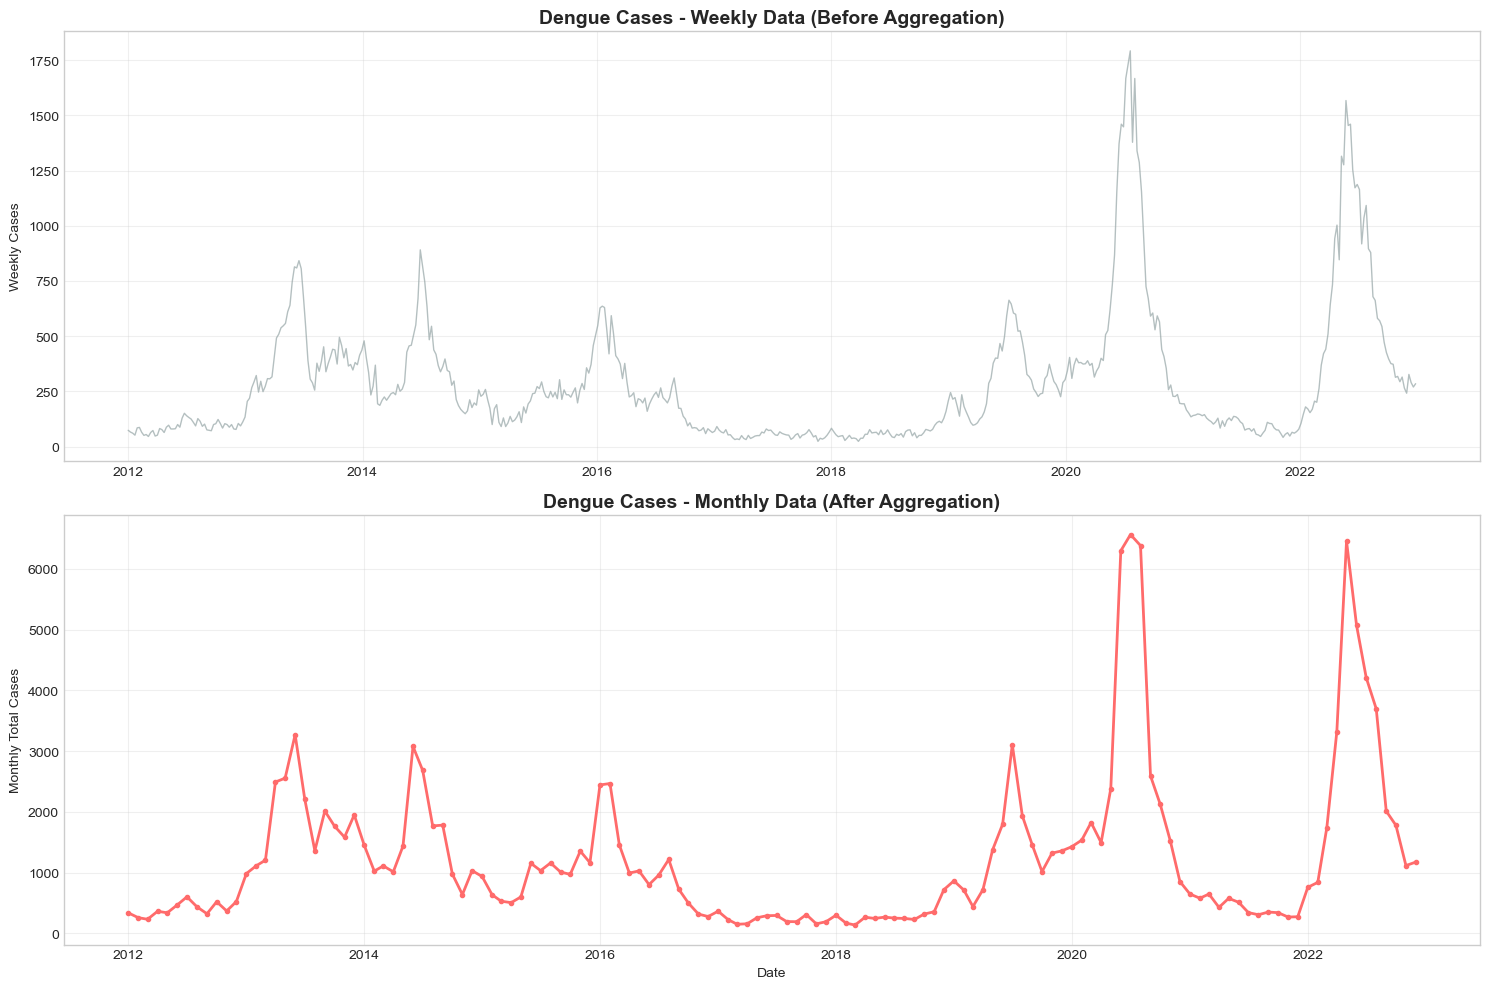

In [6]:
# Compare weekly vs monthly data visually
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Weekly data (original)
axes[0].plot(df_dengue['date'], df_dengue['cases'], 
             linewidth=1, alpha=0.7, color='#95a5a6')
axes[0].set_title('Dengue Cases - Weekly Data (Before Aggregation)', 
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Weekly Cases')
axes[0].grid(True, alpha=0.3)

# Plot 2: Monthly data (aggregated)
axes[1].plot(df_dengue_monthly['month'], df_dengue_monthly['cases'], 
             linewidth=2, color='#FF6B6B', marker='o', markersize=3)
axes[1].set_title('Dengue Cases - Monthly Data (After Aggregation)', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Monthly Total Cases')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Merge dengue (monthly) with weather (monthly)
df_merged = pd.merge(
    df_dengue_monthly,
    df_weather,
    on='month',
    how='inner'  # Only keep months where we have both dengue and weather
)

print("="*60)
print("MERGED DATASET (Monthly)")
print("="*60)
print(f"Shape: {df_merged.shape}")
print(f"Rows: {len(df_merged)} months")
print(f"Columns: {len(df_merged.columns)}")

print("\nColumns in merged dataset:")
for col in df_merged.columns:
    print(f"  • {col}")

print("\n" + "="*60)
print("SAMPLE OF MERGED DATA")
print("="*60)
print(df_merged.head(10))

print("\n" + "="*60)
print("DATE RANGE CHECK")
print("="*60)
print(f"Start date: {df_merged['month'].min().date()}")
print(f"End date: {df_merged['month'].max().date()}")
print(f"Total months with complete data: {len(df_merged)}")

MERGED DATASET (Monthly)
Shape: (132, 4)
Rows: 132 months
Columns: 4

Columns in merged dataset:
  • month
  • cases
  • rainfall
  • temperature

SAMPLE OF MERGED DATA
       month  cases  rainfall  temperature
0 2012-01-01    338     106.1         24.3
1 2012-02-01    258      83.6         24.8
2 2012-03-01    231     313.4         24.4
3 2012-04-01    363     260.6         24.8
4 2012-05-01    338     292.0         24.8
5 2012-06-01    468      53.0         26.3
6 2012-07-01    601     130.8         25.3
7 2012-08-01    436     119.0         25.4
8 2012-09-01    322     107.6         25.3
9 2012-10-01    520     122.2         25.2

DATE RANGE CHECK
Start date: 2012-01-01
End date: 2022-12-01
Total months with complete data: 132


In [8]:
# Check for missing values
print("="*60)
print("MISSING VALUES CHECK")
print("="*60)
print(df_merged.isnull().sum())

if df_merged.isnull().sum().sum() == 0:
    print("\n No missing values! Data is clean.")
else:
    print("\n Some missing values detected.")
    missing_rows = df_merged[df_merged.isnull().any(axis=1)]
    print(f"\nRows with missing values: {len(missing_rows)}")
    print(missing_rows)

# Basic statistics
print("\n" + "="*60)
print("MERGED DATA STATISTICS")
print("="*60)
print(df_merged[['cases', 'rainfall', 'temperature']].describe())

print("\n" + "="*60)
print("DATA DISTRIBUTION")
print("="*60)
print(f"Cases - Mean: {df_merged['cases'].mean():.1f}, Std: {df_merged['cases'].std():.1f}")
print(f"Rainfall - Mean: {df_merged['rainfall'].mean():.1f} mm, Std: {df_merged['rainfall'].std():.1f} mm")
print(f"Temperature - Mean: {df_merged['temperature'].mean():.1f}°C, Std: {df_merged['temperature'].std():.1f}°C")

MISSING VALUES CHECK
month          0
cases          0
rainfall       0
temperature    0
dtype: int64

 No missing values! Data is clean.

MERGED DATA STATISTICS
             cases    rainfall  temperature
count   132.000000  132.000000   132.000000
mean   1244.613636  164.350000    25.376515
std    1290.526963  101.179661     0.683375
min     136.000000    0.200000    23.800000
25%     347.750000   89.600000    24.800000
50%     947.000000  144.800000    25.350000
75%    1529.750000  216.700000    25.900000
max    6566.000000  692.800000    27.100000

DATA DISTRIBUTION
Cases - Mean: 1244.6, Std: 1290.5
Rainfall - Mean: 164.3 mm, Std: 101.2 mm
Temperature - Mean: 25.4°C, Std: 0.7°C


In [11]:
# Extract useful time-based features
df_merged['year'] = df_merged['month'].dt.year
df_merged['month_num'] = df_merged['month'].dt.month  # 1-12
df_merged['quarter'] = df_merged['month'].dt.quarter  # 1-4

print("="*60)
print("TIME FEATURES ADDED")
print("="*60)
print("New columns added:")
print("  • year (e.g., 2020)")
print("  • month_num (1-12)")
print("  • quarter (1-4)")

print("\nSample with time features:")
print(df_merged[['month', 'year', 'month_num', 'quarter', 'cases']].head(10))

print(f"\nDataset now has {len(df_merged.columns)} columns:")
print(df_merged.columns.tolist())

TIME FEATURES ADDED
New columns added:
  • year (e.g., 2020)
  • month_num (1-12)
  • quarter (1-4)

Sample with time features:
       month  year  month_num  quarter  cases
0 2012-01-01  2012          1        1    338
1 2012-02-01  2012          2        1    258
2 2012-03-01  2012          3        1    231
3 2012-04-01  2012          4        2    363
4 2012-05-01  2012          5        2    338
5 2012-06-01  2012          6        2    468
6 2012-07-01  2012          7        3    601
7 2012-08-01  2012          8        3    436
8 2012-09-01  2012          9        3    322
9 2012-10-01  2012         10        4    520

Dataset now has 7 columns:
['month', 'cases', 'rainfall', 'temperature', 'year', 'month_num', 'quarter']


In [17]:
# Save the merged monthly dataset
df_merged.to_csv('../data/processed/dengue_weather_monthly.csv', index=False)

## Data Preparation
- Converted weekly to monthly data
- Merged datasets on month
## Data Quality
- Proper monthly alignment
- No missing values
- Ready for feature engineering